In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
df = pd.read_csv("Unemployment in India.csv")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

# Check for nulls
print(df.isnull().sum())
print(df.shape)
df.head()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
(768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [12]:
print("Date Range:", df['Date'].min(), "to", df['Date'].max())
print("\nRegions:", df['Region'].nunique())
print("\nBasic Stats:")
df[['Estimated Unemployment Rate (%)']].describe()

Date Range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00

Regions: 28

Basic Stats:


,Estimated Unemployment Rate (%)
count,740.000000
mean,11.787946
std,10.721298
min,0.000000
25%,4.657500
50%,8.350000
75%,15.887500
max,76.740000


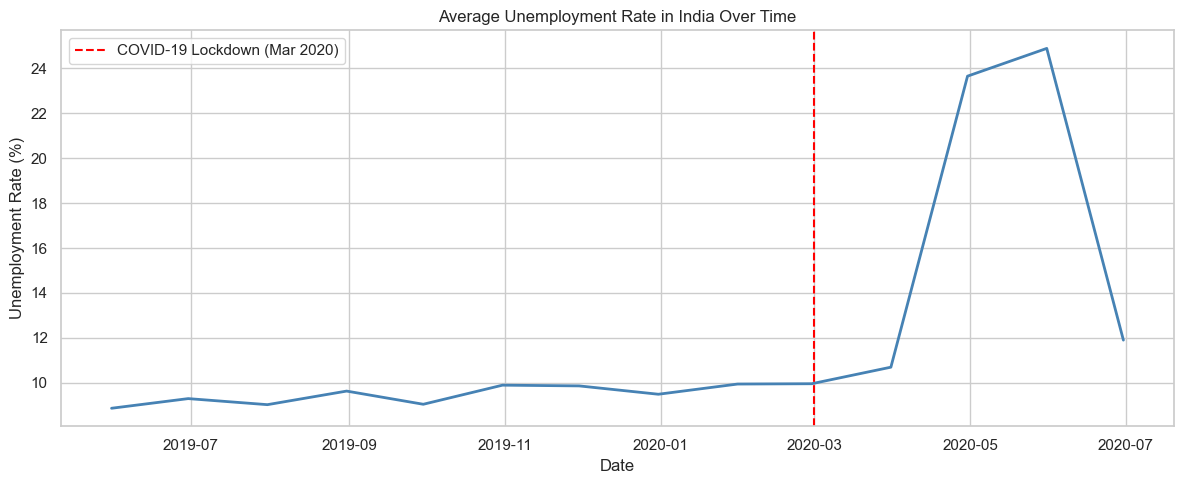

In [13]:
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Estimated Unemployment Rate (%)'], color='steelblue', linewidth=2)
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID-19 Lockdown (Mar 2020)')
plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

Period
Post-COVID    17.774363
Pre-COVID      9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


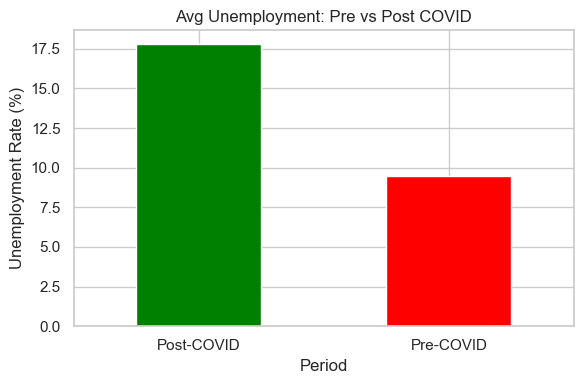

In [14]:
df['Period'] = df['Date'].apply(lambda x: 'Post-COVID' if x >= pd.to_datetime('2020-03-01') else 'Pre-COVID')

covid_compare = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()
print(covid_compare)

covid_compare.plot(kind='bar', color=['green', 'red'], figsize=(6, 4), title='Avg Unemployment: Pre vs Post COVID')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

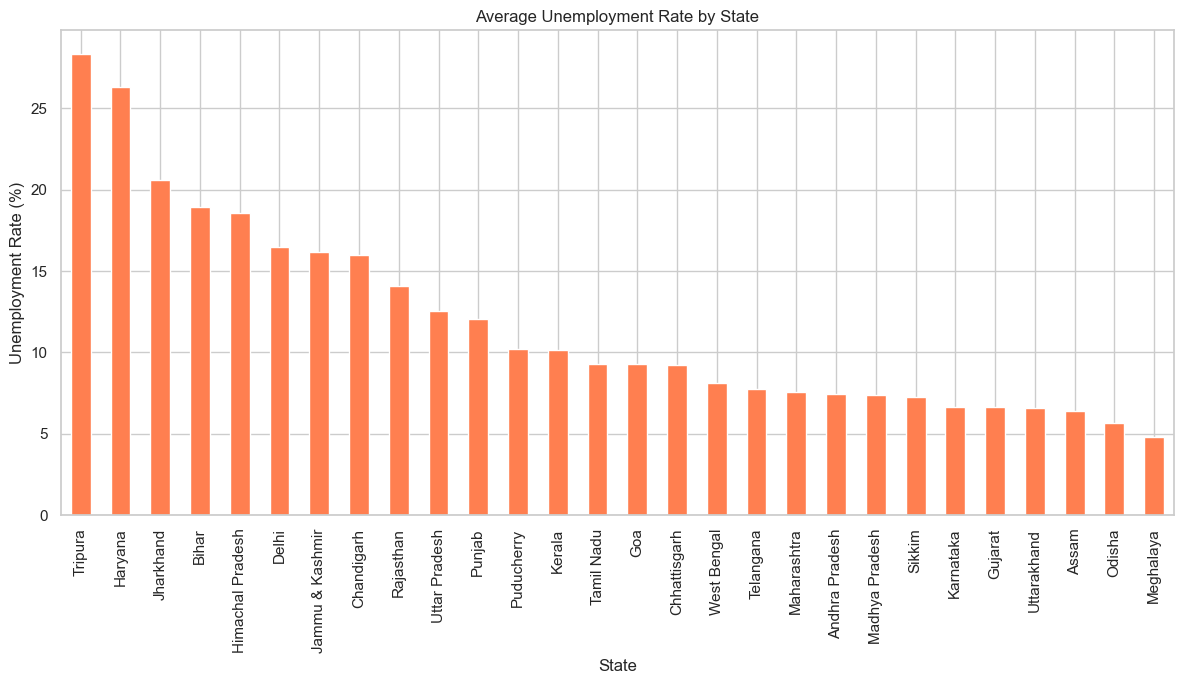

In [15]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
state_avg.plot(kind='bar', color='coral')
plt.title('Average Unemployment Rate by State')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

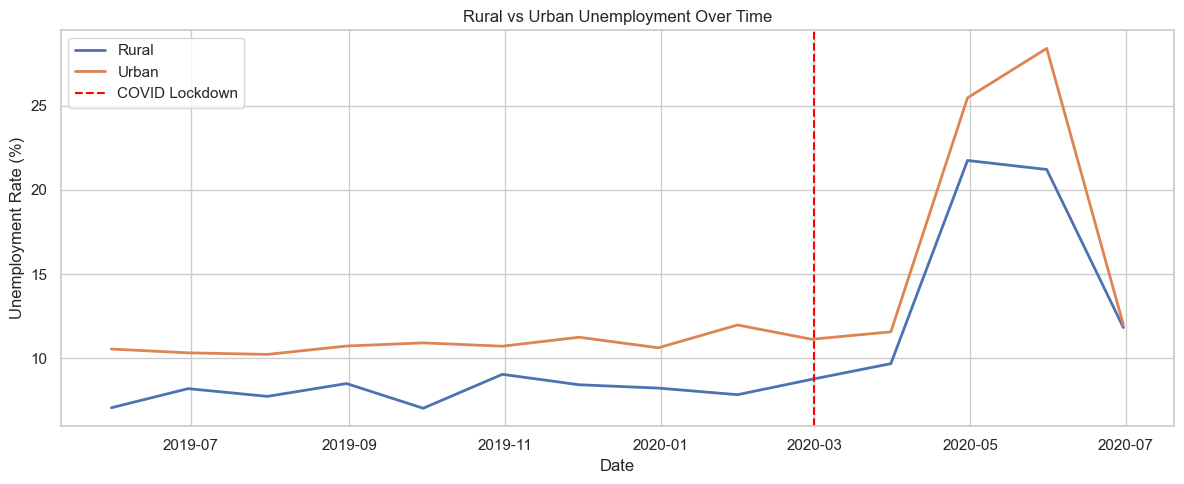

In [16]:
area_avg = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
for area in area_avg['Area'].unique():
    subset = area_avg[area_avg['Area'] == area]
    plt.plot(subset['Date'], subset['Estimated Unemployment Rate (%)'], label=area, linewidth=2)

plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID Lockdown')
plt.title('Rural vs Urban Unemployment Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

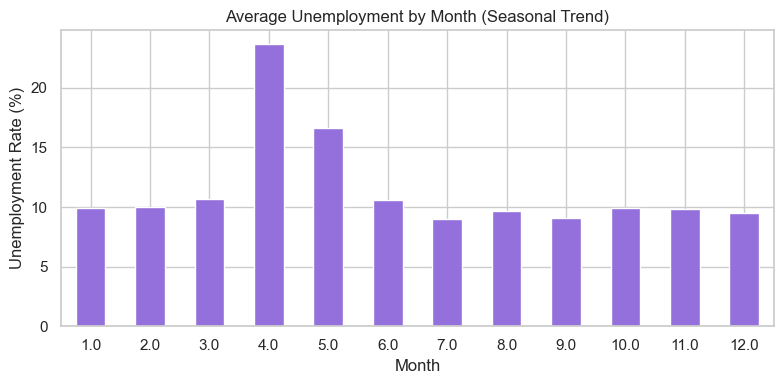

In [17]:
df['Month'] = df['Date'].dt.month

monthly_pattern = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8, 4))
monthly_pattern.plot(kind='bar', color='mediumpurple')
plt.title('Average Unemployment by Month (Seasonal Trend)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
print("""
KEY INSIGHTS:
1. Unemployment spiked sharply in April-May 2020 due to COVID-19 lockdown.
2. Post-COVID average unemployment is significantly higher than pre-COVID.
3. Urban areas were more severely impacted than rural areas during the lockdown.
4. States like Tripura and Haryana show consistently high unemployment.
5. Slight seasonal trend visible — unemployment tends to rise in certain months.

POLICY SUGGESTIONS:
- Targeted job creation schemes in high-unemployment states.
- Urban workforce safety nets for future economic disruptions.
- Skill development programs to reduce structural unemployment.
""")


KEY INSIGHTS:
1. Unemployment spiked sharply in April-May 2020 due to COVID-19 lockdown.
2. Post-COVID average unemployment is significantly higher than pre-COVID.
3. Urban areas were more severely impacted than rural areas during the lockdown.
4. States like Tripura and Haryana show consistently high unemployment.
5. Slight seasonal trend visible — unemployment tends to rise in certain months.

POLICY SUGGESTIONS:
- Targeted job creation schemes in high-unemployment states.
- Urban workforce safety nets for future economic disruptions.
- Skill development programs to reduce structural unemployment.

